In [68]:
import numpy as np
from ultralytics import YOLO
import cv2
import torch
import matplotlib.pyplot as plt
import math
from deep_sort_realtime.deepsort_tracker import DeepSort

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device: ", device)

device:  cuda


In [70]:
model_detect = YOLO("model/model_detect.pt")
model_seg = YOLO("model/model_seg.pt")

tracker = DeepSort(max_age=30)

In [17]:
img_path = r"data\detection-task\images\train\Duong_10_cam_1_38.png"

def detect_obj_on_img(img_path):
    img = cv2.imread(img_path)
    
    obj = model_detect(source=img_path, device=device, save=False, show=False)[0]
    
    for box in obj.boxes:
        x1, y1, x2, y2 = box.xyxy[0].int().tolist()
        cls = int(box.cls[0].item())
        conf = float(box.conf[0].item())
        
        label = f"{obj.names[cls] if hasattr(obj, 'names') else cls}: {conf:.2f}"
        
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img, 
            label, 
            (x1, max(y1 - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 0),
            2
        )

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize = (10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_10_cam_1_38.png: 288x512 12 xe_mays, 7 xe_otos, 1 xe_bus, 3 xe_tais, 24.6ms
Speed: 1.6ms preprocess, 24.6ms inference, 0.4ms postprocess per image at shape (1, 3, 288, 512)


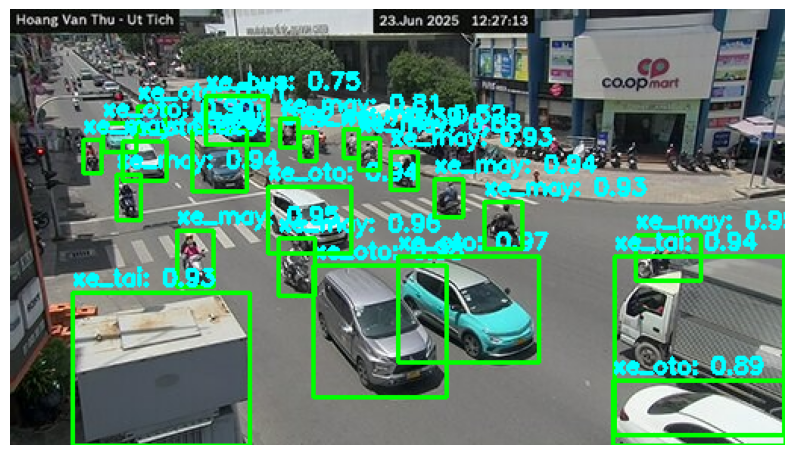

In [18]:
detect_obj_on_img(img_path)

In [93]:
def track_video(video_path: str,
                      tracker,
                      model_detect,
                      device='cuda',
                      startskip_sec: int = 5,
                      catch_sec: int = 3,
                      max_frames=None):
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    start_frame = int(startskip_sec * fps)
    end_frame = start_frame + int(catch_sec * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    # Lưu vị trí gốc (start) của mỗi track
    track_start = {}
    
    frames_out, frames_idx = [], []
    frame_count, read_count = start_frame, 0
    
    while frame_count < end_frame:
        ret, frame = cap.read()
        if not ret:
            break
        if max_frames is not None and read_count >= max_frames:
            break
        
        obj = model_detect.predict(frame, device=device, save=False, show=False)[0]
        detections = []
        for box in obj.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0].cpu().numpy())
            cls = int(box.cls[0].cpu().numpy())
            detections.append(([float(x1), float(y1), float(x2), float(y2)], conf, cls))
        
        tracks = tracker.update_tracks(detections, frame=frame)
        
        draw = frame.copy()
        for track in tracks:
            if not track.is_confirmed():
                continue
            
            track_id = track.track_id
            x1, y1, x2, y2 = map(int, track.to_ltrb())
            cx, cy = int((x1 + x2)/2), int((y1 + y2)/2)
            
            # Nếu track mới xuất hiện, lưu vị trí start
            if track_id not in track_start:
                track_start[track_id] = (cx, cy)
            
            # Vẽ vector tích lũy từ start -> frame hiện tại
            cv2.arrowedLine(draw,
                            (track_start[track_id][0], track_start[track_id][1]),
                            (cx, cy),
                            (255, 0, 0), 2, tipLength=0.3)
            
            # cv2.rectangle(draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(draw, f"ID:{track_id}", (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
        
        frames_out.append(draw)
        frames_idx.append(frame_count)
        read_count += 1
        frame_count += 1
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count)
    
    cap.release()
    return frames_out, frames_idx


def export_video(frames_list, output_path, fps):
    if len(frames_list) == 0:
        raise ValueError(f"Không có frame tồn tại")
    
    h, w = frames_list[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    for frame in frames_list:
        out.write(frame)
    out.release()
    print(f"Video đã lưu tại: {output_path}")

In [94]:
frames_drawed, frame_ids = track_video(
    video_path="data/cam-1.mp4",
    tracker= tracker,
    model_detect=model_detect,
    device='cuda',
    startskip_sec=10,   # bỏ qua 10 giây đầu
    catch_sec=20,
)

export_video(frames_drawed, "tmp/tracking.mp4", fps = 30)


0: 288x512 12 xe_mays, 4 xe_otos, 28.1ms
Speed: 17.1ms preprocess, 28.1ms inference, 1.7ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 13 xe_mays, 4 xe_otos, 19.4ms
Speed: 1.7ms preprocess, 19.4ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 12 xe_mays, 7 xe_otos, 15.7ms
Speed: 1.7ms preprocess, 15.7ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 12 xe_mays, 7 xe_otos, 11.7ms
Speed: 1.5ms preprocess, 11.7ms inference, 0.5ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 12 xe_mays, 6 xe_otos, 11.5ms
Speed: 1.5ms preprocess, 11.5ms inference, 0.5ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 12 xe_mays, 6 xe_otos, 18.9ms
Speed: 1.9ms preprocess, 18.9ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 11 xe_mays, 4 xe_otos, 11.4ms
Speed: 1.4ms preprocess, 11.4ms inference, 0.5ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 11 xe_mays, 4 